In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
import gecko

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 12,
    'figure.titlesize': 20,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})


def add_frequency_index_axis(ax, frequencies, max_ticks=14):
    vals = np.asarray(frequencies, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None

    uniq = np.unique(np.round(vals, 12))
    if uniq.size == 0:
        return None

    step = max(1, int(np.ceil(uniq.size / max_ticks)))
    tick_vals = uniq[::step]
    idx_map = {float(v): i for i, v in enumerate(uniq)}

    top = ax.twiny()
    top.set_xlim(ax.get_xlim())
    top.set_xticks(tick_vals)
    top.set_xticklabels([str(idx_map[float(v)]) for v in tick_vals])
    top.set_xlabel('Frequency index')
    top.grid(False)
    return top


RUN_ROOT = Path('/gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.350-nauto')
MOLRESPONSE_CANDIDATES = sorted(RUN_ROOT.glob('*/task_1/molresponse'))
if not MOLRESPONSE_CANDIDATES:
    raise RuntimeError(f'Could not find task_1/molresponse under {RUN_ROOT}')
MOLRESPONSE_DIR = MOLRESPONSE_CANDIDATES[0]

SHARDS = sorted(MOLRESPONSE_DIR.glob('response_metadata.group*.json'))
if not SHARDS:
    raise RuntimeError(f'No response_metadata.group*.json shards found under {MOLRESPONSE_DIR}')

CALC = None
CALC_ERROR = None
try:
    CALC = gecko.load_calc(RUN_ROOT)
except Exception as exc:
    CALC_ERROR = str(exc)

print('Run root:', RUN_ROOT)
print('Molresponse dir:', MOLRESPONSE_DIR)
print('Metadata shards:', len(SHARDS))
if CALC is None:
    print('Gecko calc load: failed')
    print('Gecko calc error:', CALC_ERROR)
else:
    print('Gecko data keys:', sorted(CALC.data.keys()))



Run root: /gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.350-nauto
Molresponse dir: /gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.350-nauto/f0-f0350_pauto/task_1/molresponse
Metadata shards: 28
Gecko data keys: ['alpha', 'beta', 'hessian', 'input_molecule', 'molecule', 'normal_modes', 'orbital_energies', 'output_molecule', 'polarization_frequencies', 'raman', 'raw_json', 'timings', 'vibrational_frequencies']


In [2]:
def build_point_table(shards):
    records = {}

    for shard in shards:
        gid = int(shard.stem.split('group')[-1])
        data = json.loads(shard.read_text())

        for state_id, state_payload in data.get('states', {}).items():
            protocols = state_payload.get('protocols', {}) or {}
            for protocol_key, protocol_payload in protocols.items():
                converged_map = protocol_payload.get('converged', {}) or {}
                saved_map = protocol_payload.get('saved', {}) or {}
                diag_map = protocol_payload.get('solver_diagnostics', {}) or {}
                prov_map = protocol_payload.get('restart_provenance', {}) or {}
                timing_map = protocol_payload.get('timings', {}) or {}

                owned_point_keys = set(diag_map.keys()) | set(prov_map.keys()) | set(timing_map.keys())
                all_point_keys = set(converged_map.keys()) | set(saved_map.keys()) | owned_point_keys

                for freq_str in all_point_keys:
                    key = (state_id, protocol_key, freq_str)
                    row = records.setdefault(
                        key,
                        {
                            'state': state_id,
                            'protocol': protocol_key,
                            'frequency': float(freq_str),
                            'saved': False,
                            'converged': False,
                            'iterations': np.nan,
                            'final_residual': np.nan,
                            'final_drho': np.nan,
                            'wall_seconds': np.nan,
                            'cpu_seconds': np.nan,
                            'restart_kind': 'unknown',
                            'groups': set(),
                        },
                    )

                    if freq_str in owned_point_keys:
                        row['groups'].add(gid)

                    row['saved'] = row['saved'] or bool(saved_map.get(freq_str, False))
                    row['converged'] = row['converged'] or bool(converged_map.get(freq_str, False))

                    diag = diag_map.get(freq_str)
                    if isinstance(diag, dict):
                        if diag.get('iterations_performed') is not None:
                            row['iterations'] = float(diag['iterations_performed'])
                        if diag.get('final_residual_norm') is not None:
                            row['final_residual'] = float(diag['final_residual_norm'])
                        if diag.get('final_density_change') is not None:
                            row['final_drho'] = float(diag['final_density_change'])

                    timing = timing_map.get(freq_str)
                    if isinstance(timing, dict):
                        if timing.get('wall_seconds') is not None:
                            row['wall_seconds'] = float(timing['wall_seconds'])
                        if timing.get('cpu_seconds') is not None:
                            row['cpu_seconds'] = float(timing['cpu_seconds'])

                    prov = prov_map.get(freq_str)
                    if isinstance(prov, dict):
                        kind = prov.get('kind')
                        if kind:
                            row['restart_kind'] = kind

    rows = []
    for row in records.values():
        row = dict(row)
        row['groups'] = sorted(row['groups'])
        row['owner_group'] = int(row['groups'][0]) if len(row['groups']) == 1 else np.nan
        rows.append(row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).sort_values(['protocol', 'state', 'frequency']).reset_index(drop=True)
    channel_label = {'Dipole_x': 'DipoleX', 'Dipole_y': 'DipoleY', 'Dipole_z': 'DipoleZ'}
    df['channel'] = df['state'].map(channel_label).fillna(df['state'])
    return df


channel_order = ['DipoleX', 'DipoleY', 'DipoleZ']
channel_colors = {'DipoleX': '#1f77b4', 'DipoleY': '#2ca02c', 'DipoleZ': '#d62728'}
restart_markers = {
    'initial_guess': 'o',
    'coarser_protocol_archive': 's',
    'previous_frequency_archive': '^',
    'previous_frequency_memory': 'D',
    'same_protocol_archive': 'P',
    'unknown': 'X',
}

DF = build_point_table(SHARDS)
if DF.empty:
    raise RuntimeError('Parsed point table is empty; metadata shards may be incomplete.')

PROTOCOLS = sorted(DF['protocol'].unique(), key=float, reverse=True)

summary_rows = []
for p in PROTOCOLS:
    sub = DF[DF['protocol'] == p]
    summary_rows.append({
        'protocol': p,
        'points_total': int(len(sub)),
        'points_saved': int(sub['saved'].sum()),
        'points_converged': int(sub['converged'].sum()),
        'points_with_timing': int(np.isfinite(sub['wall_seconds']).sum()),
        'mean_iterations': float(sub['iterations'].mean()),
        'mean_final_residual': float(sub['final_residual'].mean()),
        'mean_wall_s': float(sub['wall_seconds'].mean()),
    })

display(pd.DataFrame(summary_rows))

restart_counts = (
    DF.groupby(['protocol', 'restart_kind'])
    .size()
    .unstack(fill_value=0)
    .reindex(PROTOCOLS)
)
print('Restart strategy counts by protocol:')
display(restart_counts)



,protocol,points_total,points_saved,points_converged,points_with_timing,mean_iterations,mean_final_residual,mean_wall_s
0,1e-02,33,33,33,33,3.242424,0.818343,21.100334
1,1e-04,33,33,29,33,12.272727,0.012275,175.875802
2,1e-06,33,33,32,33,7.818182,0.001861,326.383697


Restart strategy counts by protocol:


restart_kind,coarser_protocol_archive,initial_guess,previous_frequency_archive
protocol,,,
1e-02,0,19,14
1e-04,22,11,0
1e-06,33,0,0


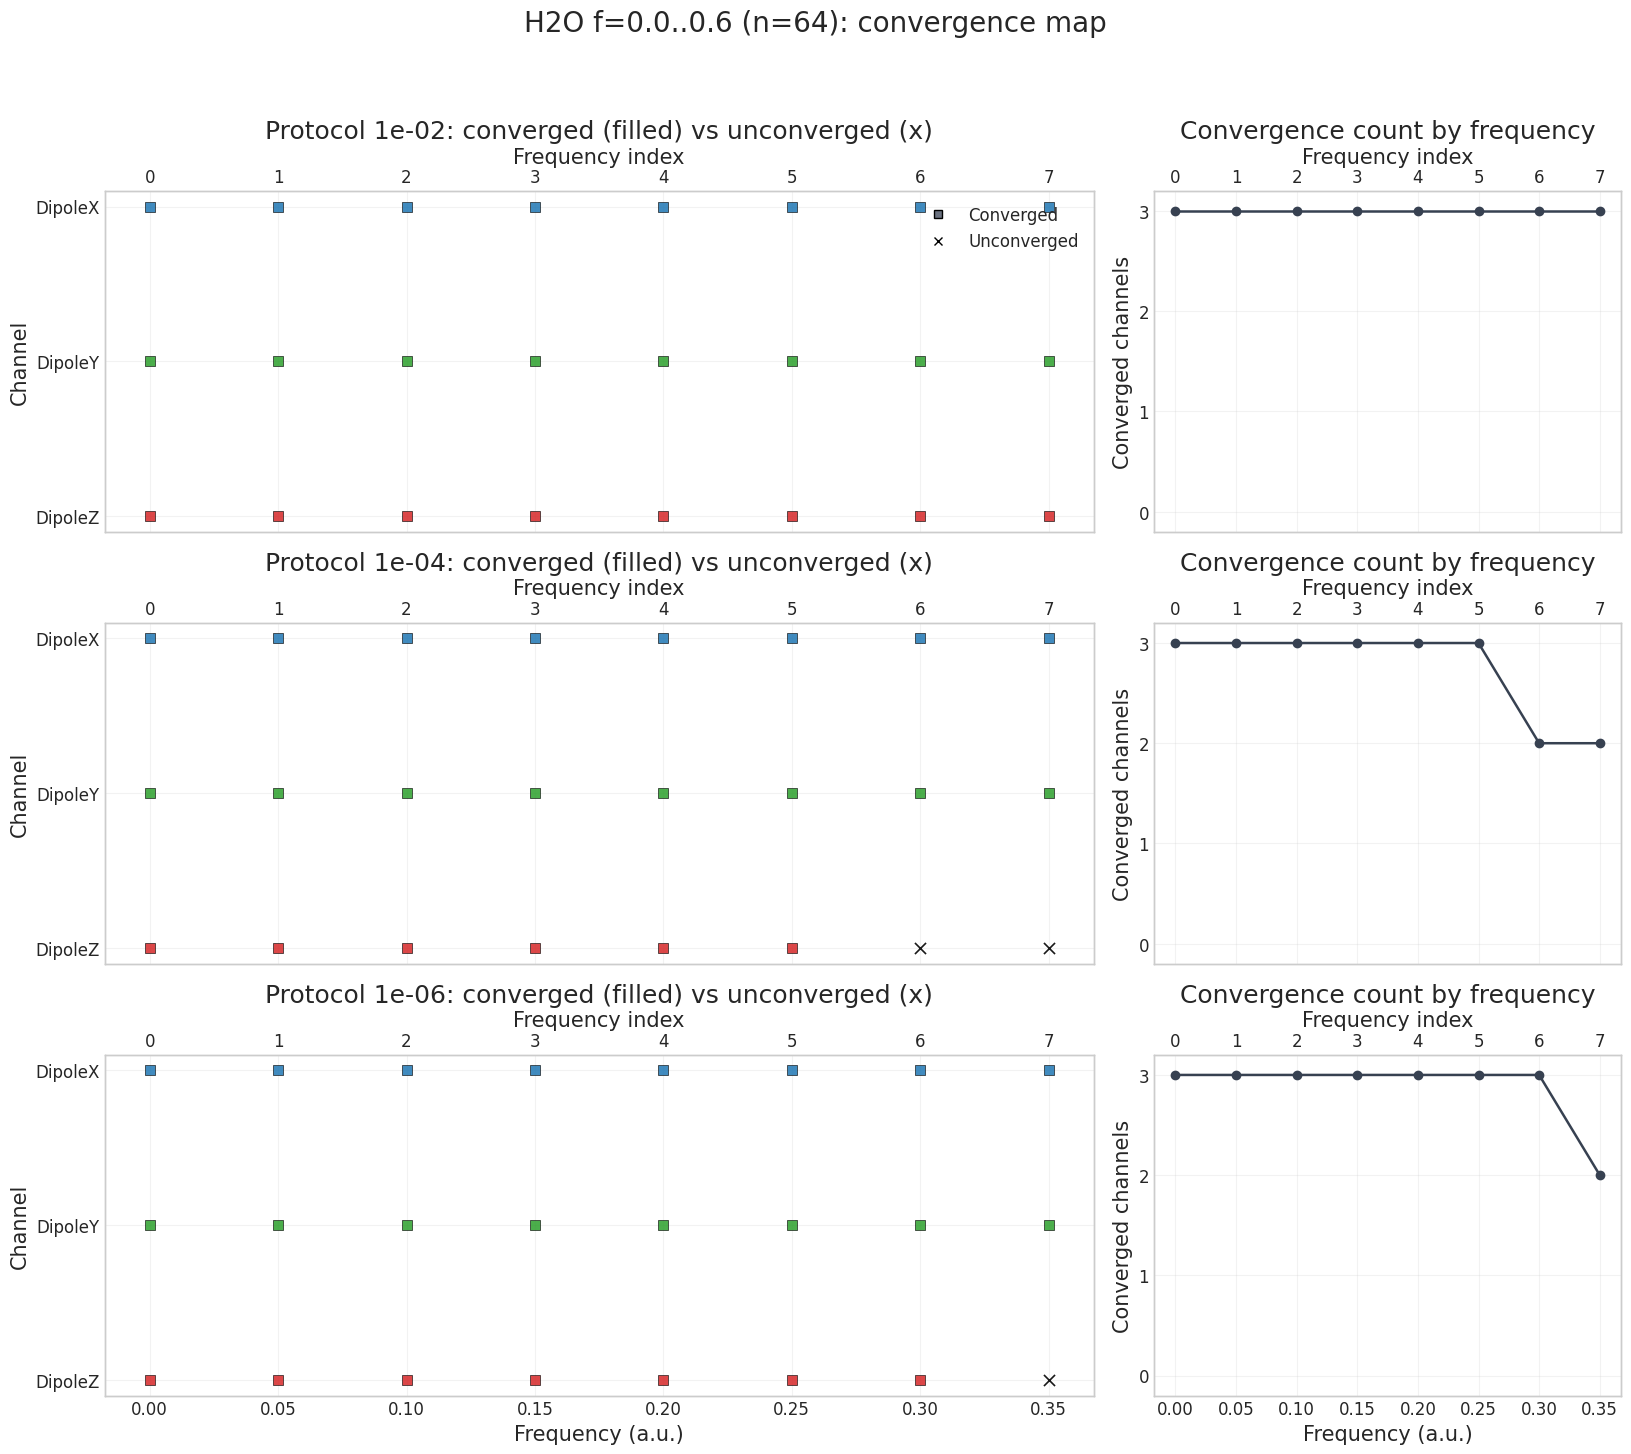

In [3]:
# Convergence map: clearly show which frequencies converged vs not converged.
fig, axes = plt.subplots(
    len(PROTOCOLS),
    2,
    figsize=(16.5, 4.8 * len(PROTOCOLS)),
    gridspec_kw={'width_ratios': [3.6, 1.7]},
    sharex='col',
)
if len(PROTOCOLS) == 1:
    axes = np.array([axes])

for i, protocol in enumerate(PROTOCOLS):
    ax_map = axes[i, 0]
    ax_cnt = axes[i, 1]

    sub = DF[DF['protocol'] == protocol].copy()
    y_map = {'DipoleX': 2, 'DipoleY': 1, 'DipoleZ': 0}

    for channel in channel_order:
        ch = sub[sub['channel'] == channel].sort_values('frequency')
        if ch.empty:
            continue

        y = np.full(len(ch), y_map[channel], dtype=float)
        conv = ch['converged'].to_numpy(dtype=bool)

        if conv.any():
            ax_map.scatter(
                ch.loc[conv, 'frequency'],
                y[conv],
                marker='s',
                s=62,
                c=channel_colors[channel],
                alpha=0.85,
                edgecolors='black',
                linewidths=0.5,
            )
        if (~conv).any():
            ax_map.scatter(
                ch.loc[~conv, 'frequency'],
                y[~conv],
                marker='x',
                s=64,
                c='black',
                alpha=0.9,
                linewidths=1.2,
            )

    ax_map.set_yticks([0, 1, 2])
    ax_map.set_yticklabels(['DipoleZ', 'DipoleY', 'DipoleX'])
    ax_map.set_ylabel('Channel')
    ax_map.set_title(f'Protocol {protocol}: converged (filled) vs unconverged (x)')
    ax_map.grid(alpha=0.25)
    add_frequency_index_axis(ax_map, sub['frequency'].to_numpy())

    conv_count = (
        sub.pivot_table(index='frequency', columns='channel', values='converged', aggfunc='max')
        .reindex(columns=channel_order)
        .fillna(False)
        .astype(int)
        .sum(axis=1)
        .sort_index()
    )
    ax_cnt.plot(conv_count.index, conv_count.values, marker='o', linewidth=1.8, color='#374151')
    ax_cnt.set_ylim(-0.2, 3.2)
    ax_cnt.set_yticks([0, 1, 2, 3])
    ax_cnt.set_ylabel('Converged channels')
    ax_cnt.set_title('Convergence count by frequency')
    ax_cnt.grid(alpha=0.25)
    add_frequency_index_axis(ax_cnt, conv_count.index.to_numpy())

axes[-1, 0].set_xlabel('Frequency (a.u.)')
axes[-1, 1].set_xlabel('Frequency (a.u.)')

legend_handles = [
    Line2D([0], [0], marker='s', color='none', markerfacecolor='#6b7280', markeredgecolor='black', label='Converged'),
    Line2D([0], [0], marker='x', color='black', linestyle='None', label='Unconverged'),
]
axes[0, 0].legend(handles=legend_handles, loc='upper right')

plt.suptitle('H2O f=0.0..0.6 (n=64): convergence map', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



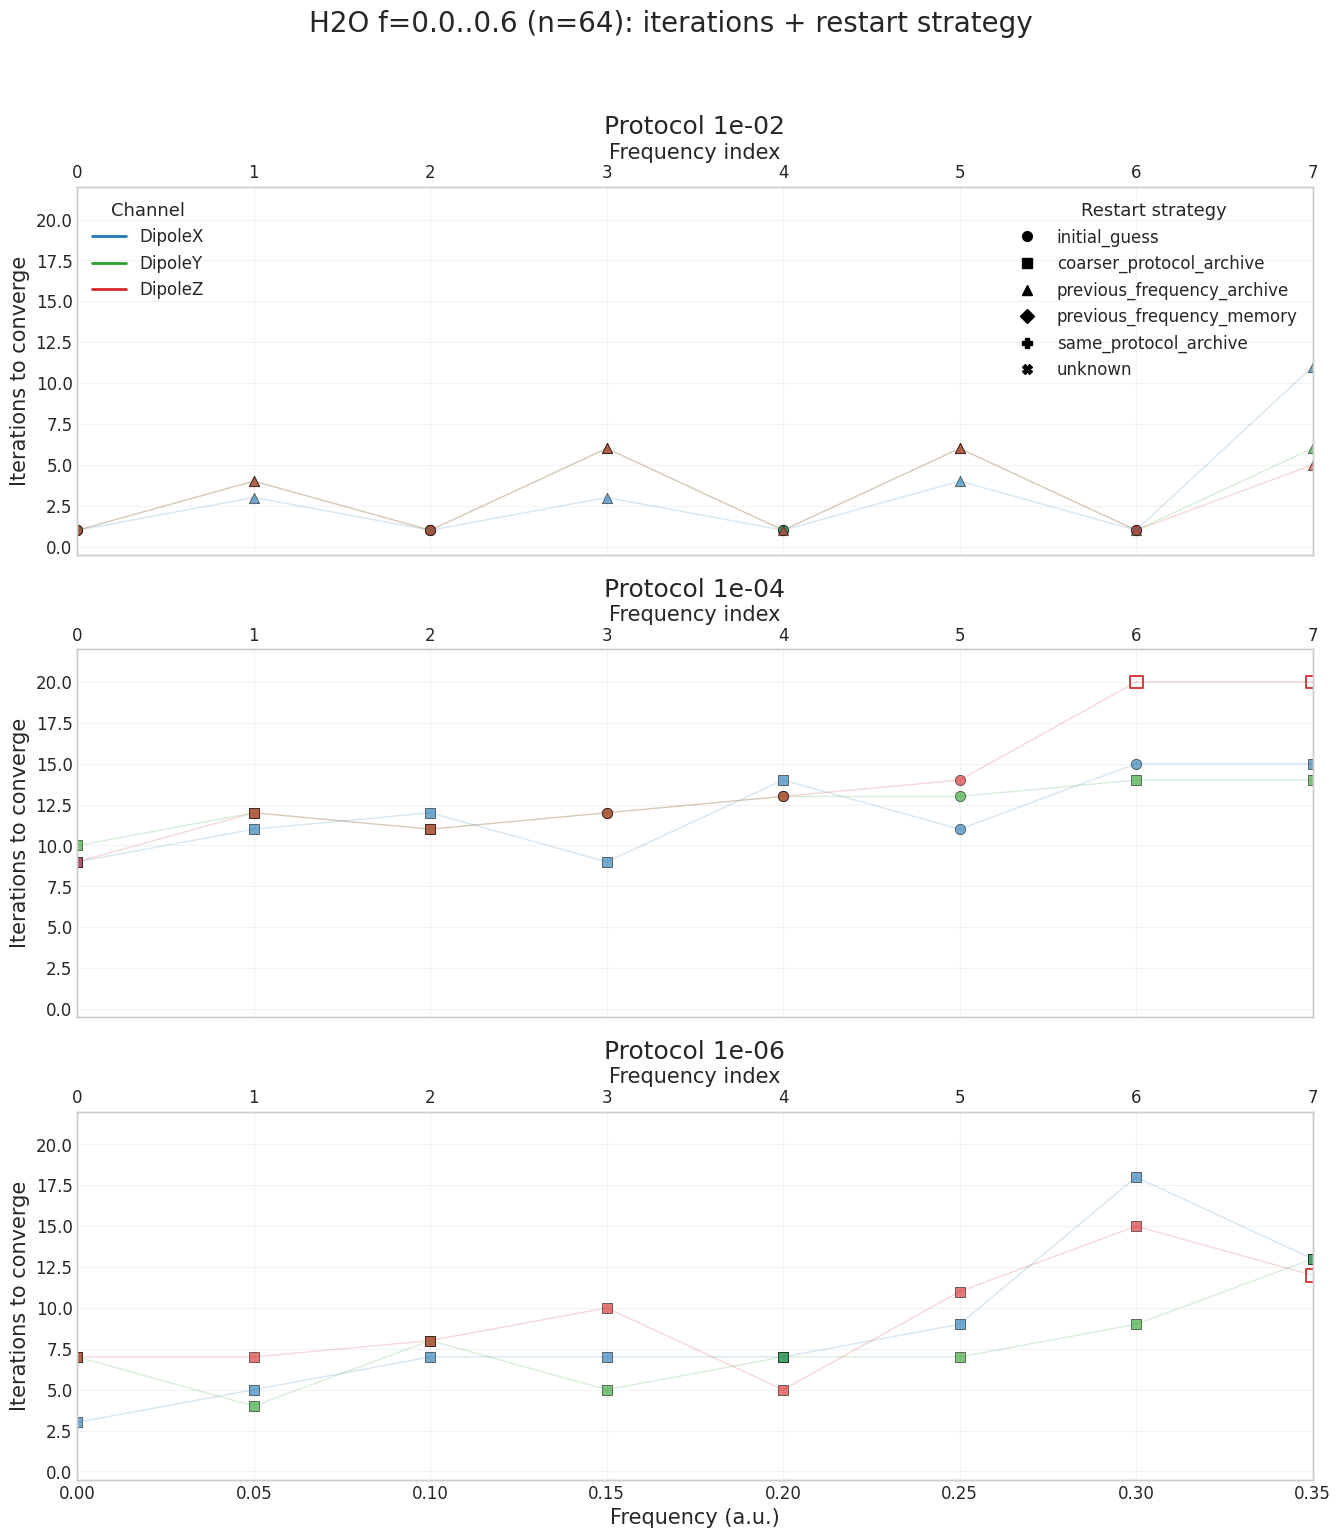

In [4]:
# Iterations vs frequency with restart strategy markers.
iter_vals = DF['iterations'].to_numpy(dtype=float)
iter_vals = iter_vals[np.isfinite(iter_vals)]
iter_max = float(iter_vals.max()) if iter_vals.size else 1.0
iter_upper = max(5.0, np.ceil(iter_max * 1.10))

freq_vals = DF['frequency'].to_numpy(dtype=float)
freq_vals = freq_vals[np.isfinite(freq_vals)]
x_min = float(freq_vals.min()) if freq_vals.size else 0.0
x_max = float(freq_vals.max()) if freq_vals.size else 1.0

fig, axes = plt.subplots(
    len(PROTOCOLS),
    1,
    figsize=(13.6, 5.1 * len(PROTOCOLS)),
    sharex=True,
    sharey=True,
)
if len(PROTOCOLS) == 1:
    axes = [axes]

for ax, protocol in zip(axes, PROTOCOLS):
    sub = DF[DF['protocol'] == protocol].copy()

    for channel in channel_order:
        sub_ch = sub[sub['channel'] == channel]
        if sub_ch.empty:
            continue

        sub_ch_sorted = sub_ch.sort_values('frequency')
        ax.plot(
            sub_ch_sorted['frequency'],
            sub_ch_sorted['iterations'],
            color=channel_colors[channel],
            linewidth=1.0,
            alpha=0.18,
        )

        for strategy, marker in restart_markers.items():
            sub_sel = sub_ch[sub_ch['restart_kind'] == strategy]
            if sub_sel.empty:
                continue

            converged = sub_sel[sub_sel['converged']]
            unconverged = sub_sel[~sub_sel['converged']]

            if not converged.empty:
                ax.scatter(
                    converged['frequency'],
                    converged['iterations'],
                    c=channel_colors[channel],
                    marker=marker,
                    s=55,
                    alpha=0.62,
                    linewidths=0.6,
                    edgecolors='black',
                )
            if not unconverged.empty:
                ax.scatter(
                    unconverged['frequency'],
                    unconverged['iterations'],
                    c='none',
                    edgecolors=channel_colors[channel],
                    marker=marker,
                    s=85,
                    linewidths=1.4,
                    alpha=0.9,
                )

    ax.set_title(f'Protocol {protocol}')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.5, iter_upper)
    ax.set_ylabel('Iterations to converge')
    ax.grid(alpha=0.25)
    add_frequency_index_axis(ax, sub['frequency'].to_numpy())

axes[-1].set_xlabel('Frequency (a.u.)')

channel_handles = [
    Line2D([0], [0], color=channel_colors[ch], lw=2, label=ch)
    for ch in channel_order
]
restart_handles = [
    Line2D([0], [0], marker=m, color='black', linestyle='None', markersize=7, label=k)
    for k, m in restart_markers.items()
]

legend1 = axes[0].legend(handles=channel_handles, title='Channel', loc='upper left')
axes[0].add_artist(legend1)
axes[0].legend(handles=restart_handles, title='Restart strategy', loc='upper right', ncol=1)

plt.suptitle('H2O f=0.0..0.6 (n=64): iterations + restart strategy', y=1.005)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



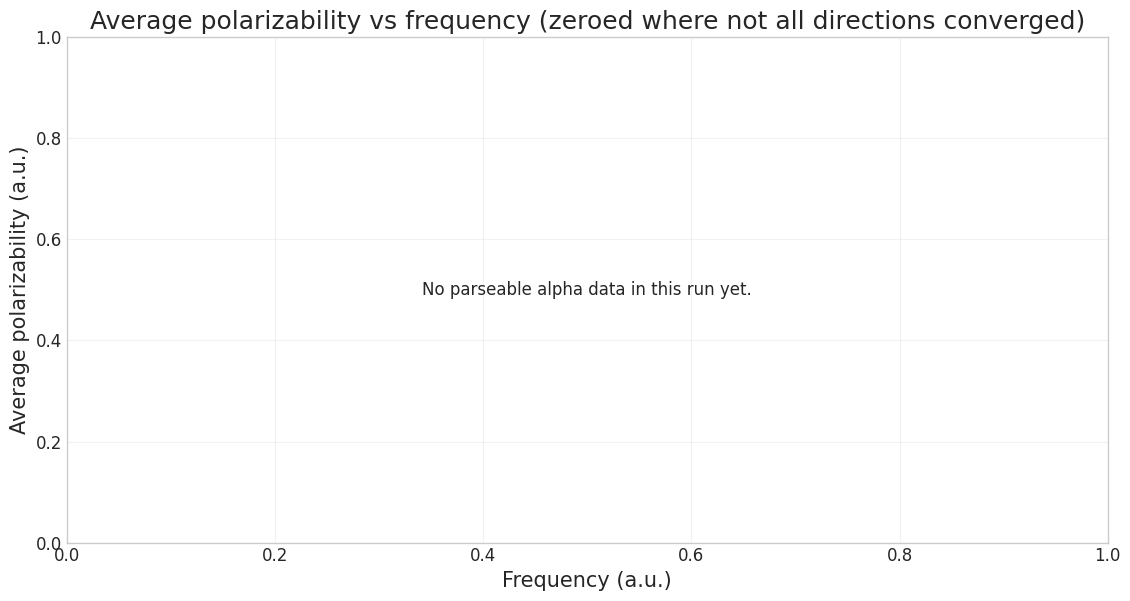

In [5]:
# Average polarizability vs frequency.
def extract_alpha_profile(calc):
    alpha = calc.data.get('alpha')
    if not isinstance(alpha, dict) or not alpha:
        return None

    omega_raw = alpha.get('omega', [])
    values_raw = alpha.get('values', [])
    components = [str(c).lower() for c in alpha.get('components', [])]

    omega = np.asarray(omega_raw, dtype=float).reshape(-1)
    values = np.asarray(values_raw, dtype=float)

    if omega.size == 0 or values.size == 0:
        return None

    if values.ndim == 1:
        if len(components) > 0 and (values.size % len(components) == 0):
            values = values.reshape(-1, len(components))
        elif omega.size > 0 and (values.size % omega.size == 0):
            values = values.reshape(omega.size, -1)
        else:
            return None

    if values.shape[0] != omega.size:
        if values.ndim == 2 and values.shape[1] == omega.size:
            values = values.T
        else:
            return None

    if len(components) and len(components) == values.shape[1]:
        component_to_idx = {c: i for i, c in enumerate(components)}
        if not all(c in component_to_idx for c in ('xx', 'yy', 'zz')):
            return None
        idx_xx, idx_yy, idx_zz = component_to_idx['xx'], component_to_idx['yy'], component_to_idx['zz']
    elif values.shape[1] >= 9:
        idx_xx, idx_yy, idx_zz = 0, 4, 8
    else:
        return None

    alpha_avg = (values[:, idx_xx] + values[:, idx_yy] + values[:, idx_zz]) / 3.0
    return omega, alpha_avg


def build_all_direction_convergence_mask(df):
    if df.empty:
        return {}

    p_final = float(np.nanmin(pd.to_numeric(df['protocol'], errors='coerce').to_numpy(dtype=float)))
    sub = df[np.isclose(pd.to_numeric(df['protocol'], errors='coerce').to_numpy(dtype=float), p_final)].copy()
    if sub.empty:
        return {}

    pivot = (
        sub.pivot_table(index='frequency', columns='channel', values='converged', aggfunc='max')
        .reindex(columns=channel_order)
        .fillna(False)
    )
    all_ok = pivot.all(axis=1)
    return {round(float(freq), 12): bool(flag) for freq, flag in all_ok.items()}


fig, ax = plt.subplots(1, 1, figsize=(11.5, 6.2))
if CALC is None:
    msg = CALC_ERROR or 'No gecko calc data available.'
    ax.text(0.5, 0.5, msg, ha='center', va='center', transform=ax.transAxes, fontsize=12, wrap=True)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
else:
    profile = extract_alpha_profile(CALC)
    if profile is None:
        ax.text(0.5, 0.5, 'No parseable alpha data in this run yet.', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.0)
    else:
        omega, alpha_avg = profile

        conv_map = build_all_direction_convergence_mask(DF)
        all_conv_mask = np.array([conv_map.get(round(float(w), 12), False) for w in omega], dtype=bool)

        y_plot = alpha_avg.copy()
        y_plot[~all_conv_mask] = 0.0

        if np.any(all_conv_mask):
            ax.plot(
                omega[all_conv_mask],
                y_plot[all_conv_mask],
                color='#4c1d95',
                marker='o',
                markersize=4,
                linewidth=1.8,
                alpha=0.90,
                label='alpha_avg (all directions converged)',
            )

        if np.any(~all_conv_mask):
            ax.scatter(
                omega[~all_conv_mask],
                np.zeros(np.sum(~all_conv_mask), dtype=float),
                marker='x',
                s=66,
                linewidths=1.6,
                color='black',
                alpha=0.9,
                label='not converged in all directions (zeroed)',
            )

        ax.set_xlim(float(np.min(omega)), float(np.max(omega)))
        finite_conv = y_plot[all_conv_mask]
        if finite_conv.size:
            y_min = float(np.min(finite_conv))
            y_max = float(np.max(finite_conv))
            y_pad = 0.05 * (y_max - y_min) if (y_max - y_min) > 1e-12 else 0.05
            ax.set_ylim(min(0.0, y_min - y_pad), y_max + y_pad)
        else:
            ax.set_ylim(-0.05, 0.05)

        add_frequency_index_axis(ax, omega)
        ax.legend(loc='best')

        dropped = omega[~all_conv_mask]
        if dropped.size:
            print('Frequencies zeroed due to incomplete directional convergence:')
            print(', '.join(f'{float(w):.6f}' for w in np.sort(dropped)))

ax.set_xlabel('Frequency (a.u.)')
ax.set_ylabel('Average polarizability (a.u.)')
ax.set_title('Average polarizability vs frequency (zeroed where not all directions converged)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()



/tmp/ipykernel_2869193/1347252848.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


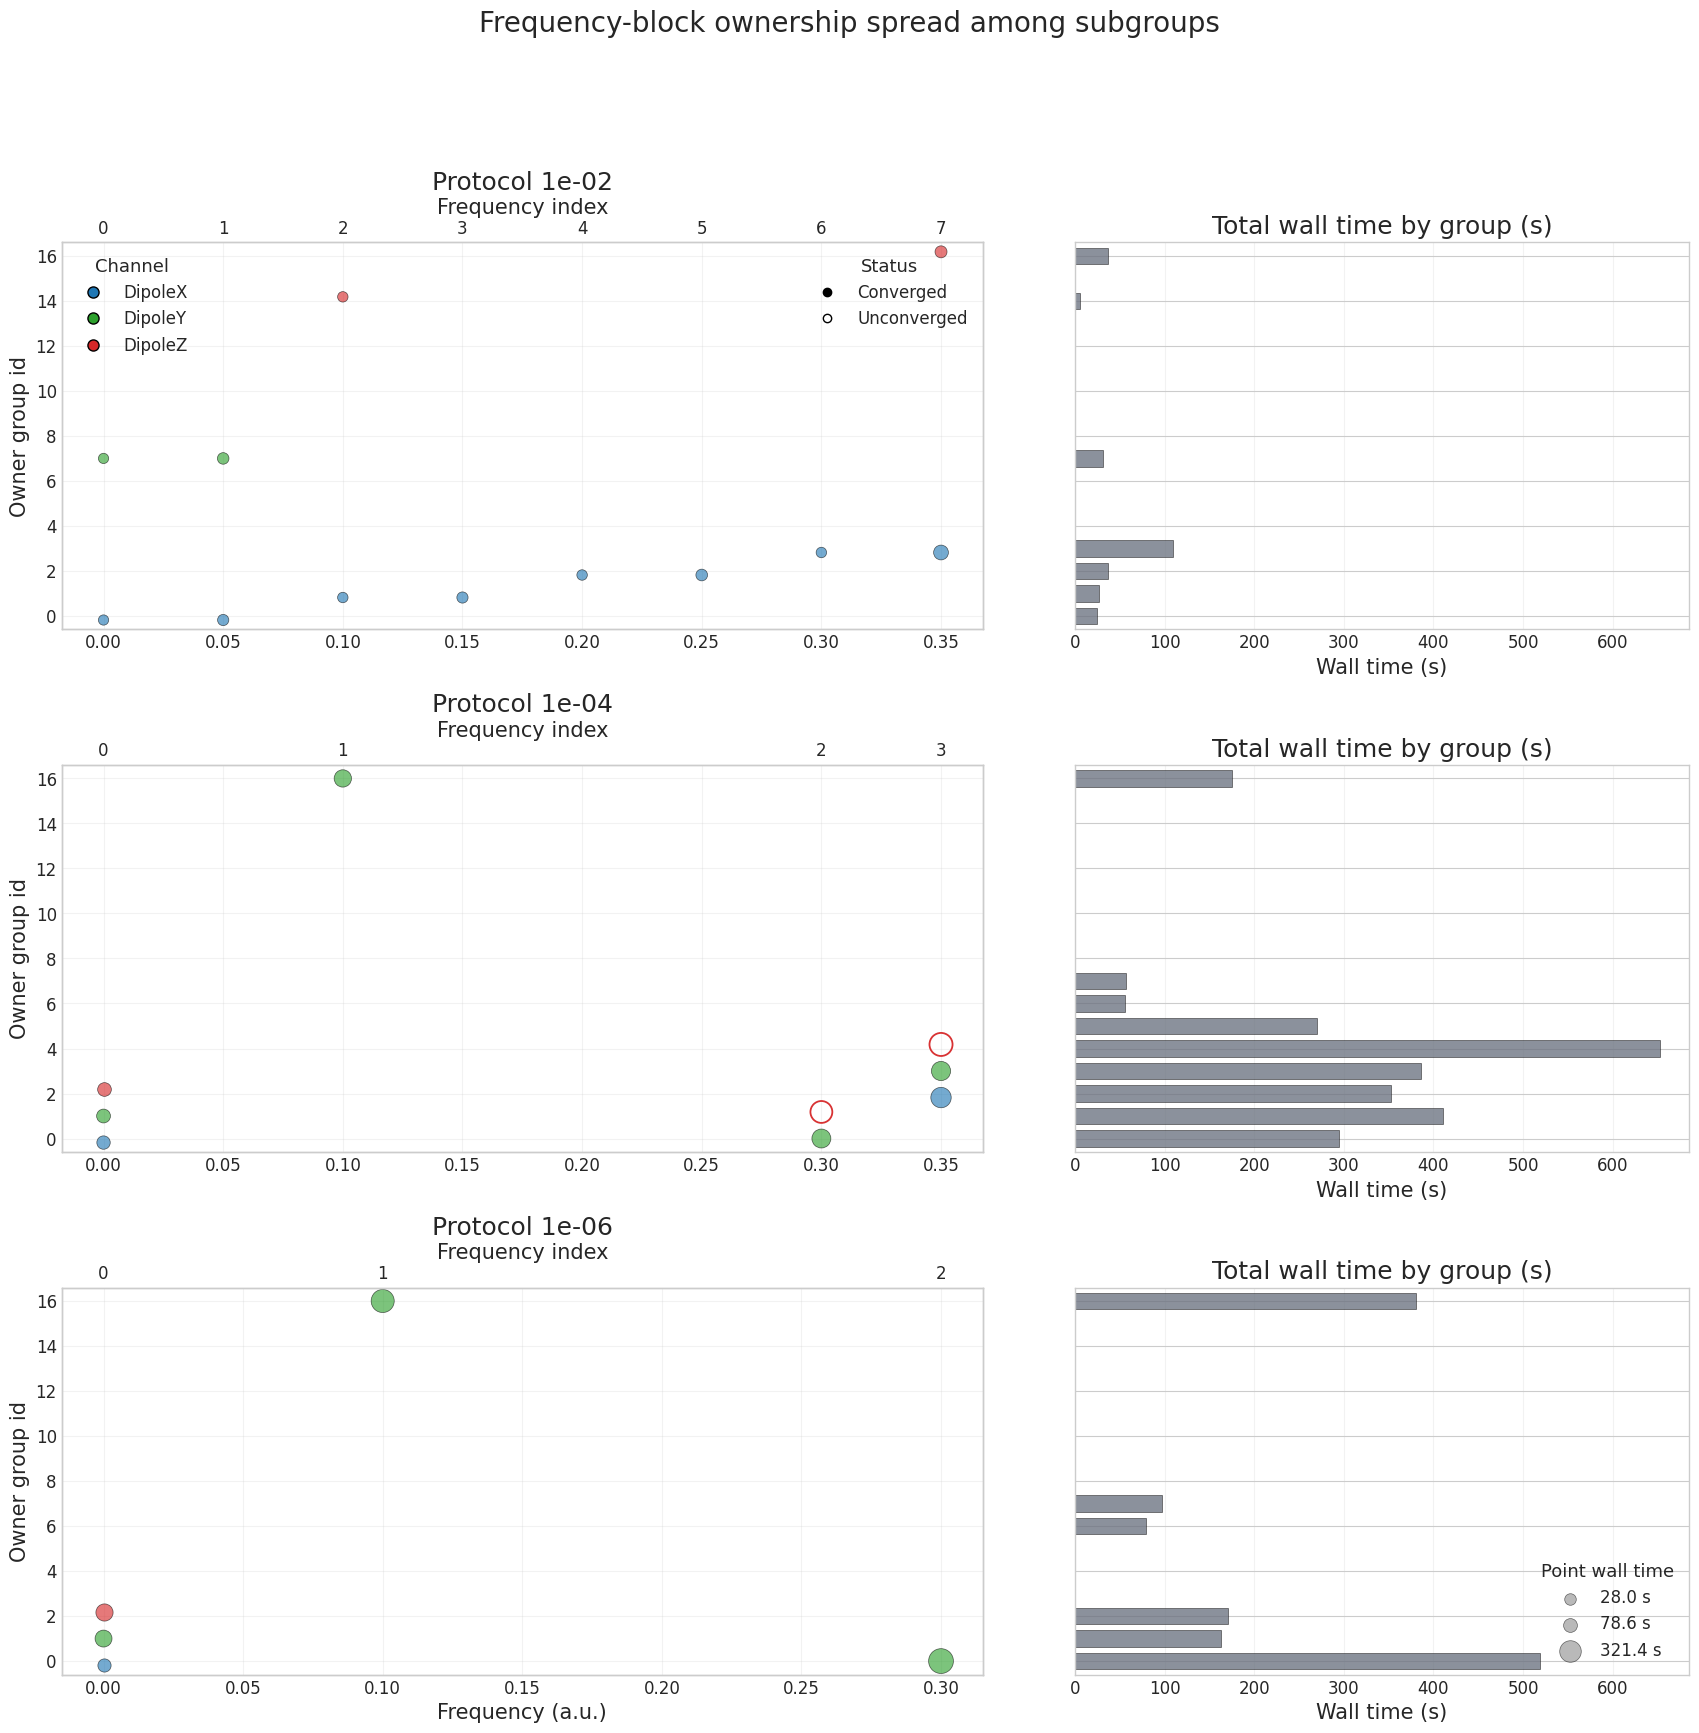

In [6]:
# Frequency-block ownership + per-group total wall-time.
OWN = DF.dropna(subset=['owner_group', 'wall_seconds']).copy()
if OWN.empty:
    raise RuntimeError('No ownership/timing rows found in metadata.')

OWN['owner_group'] = OWN['owner_group'].astype(int)
owner_groups = sorted(OWN['owner_group'].unique().tolist())
wall_min = float(OWN['wall_seconds'].min())
wall_max = float(OWN['wall_seconds'].max())
y_min = min(owner_groups) - 0.6
y_max = max(owner_groups) + 0.6

bar_max = float(OWN.groupby(['protocol', 'owner_group'])['wall_seconds'].sum().max())
bar_max = max(bar_max, 1e-9)


def point_size(values):
    vals = np.asarray(values, dtype=float)
    if not np.isfinite(wall_max - wall_min) or (wall_max - wall_min) < 1e-12:
        return np.full_like(vals, 90.0)
    return 55.0 + 265.0 * ((vals - wall_min) / (wall_max - wall_min))


fig = plt.figure(figsize=(21, 6.2 * len(PROTOCOLS)))
grid = fig.add_gridspec(
    nrows=len(PROTOCOLS),
    ncols=2,
    width_ratios=[3.6, 2.4],
    wspace=0.12,
    hspace=0.35,
)

scatter_axes = []
bar_axes = []

for i, protocol in enumerate(PROTOCOLS):
    ax = fig.add_subplot(grid[i, 0])
    ax_bar = fig.add_subplot(grid[i, 1], sharey=ax)
    scatter_axes.append(ax)
    bar_axes.append(ax_bar)

    sub = OWN[OWN['protocol'] == protocol].copy()

    for channel in channel_order:
        ch = sub[sub['channel'] == channel].sort_values('frequency')
        if ch.empty:
            continue

        y = ch['owner_group'].to_numpy(dtype=float) + {'DipoleX': -0.18, 'DipoleY': 0.0, 'DipoleZ': 0.18}[channel]
        sizes = point_size(ch['wall_seconds'])
        conv = ch['converged'].to_numpy(dtype=bool)

        if conv.any():
            ax.scatter(
                ch.loc[conv, 'frequency'],
                y[conv],
                s=sizes[conv],
                c=channel_colors[channel],
                alpha=0.62,
                edgecolors='black',
                linewidths=0.5,
            )

        if (~conv).any():
            ax.scatter(
                ch.loc[~conv, 'frequency'],
                y[~conv],
                s=sizes[~conv],
                facecolors='none',
                edgecolors=channel_colors[channel],
                alpha=0.95,
                linewidths=1.3,
            )

    totals = (
        sub.groupby('owner_group')['wall_seconds']
        .sum()
        .reindex(owner_groups, fill_value=0.0)
    )

    ax_bar.barh(
        owner_groups,
        totals.values,
        color='#6b7280',
        alpha=0.78,
        height=0.72,
        edgecolor='black',
        linewidth=0.4,
    )

    ax.set_ylim(y_min, y_max)
    ax_bar.set_ylim(y_min, y_max)
    ax_bar.set_xlim(0.0, 1.05 * bar_max)

    ax.set_title(f'Protocol {protocol}')
    ax.set_ylabel('Owner group id')
    ax.grid(alpha=0.25)
    add_frequency_index_axis(ax, sub['frequency'].to_numpy())

    ax_bar.set_title('Total wall time by group (s)')
    ax_bar.set_xlabel('Wall time (s)')
    ax_bar.grid(axis='x', alpha=0.25)
    ax_bar.tick_params(axis='y', labelleft=False)

scatter_axes[-1].set_xlabel('Frequency (a.u.)')

channel_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=channel_colors[ch], markeredgecolor='black', markersize=8, label=ch)
    for ch in channel_order
]
status_handles = [
    Line2D([0], [0], marker='o', color='black', markerfacecolor='black', linestyle='None', label='Converged'),
    Line2D([0], [0], marker='o', color='black', markerfacecolor='none', linestyle='None', label='Unconverged'),
]

legend1 = scatter_axes[0].legend(handles=channel_handles, title='Channel', loc='upper left')
scatter_axes[0].add_artist(legend1)
scatter_axes[0].legend(handles=status_handles, title='Status', loc='upper right')

q = np.quantile(OWN['wall_seconds'].to_numpy(dtype=float), [0.25, 0.5, 0.9])
size_handles = [
    plt.scatter([], [], s=point_size(np.array([v]))[0], color='gray', alpha=0.55, edgecolors='black', linewidths=0.5, label=f'{v:.1f} s')
    for v in q
]
bar_axes[-1].legend(handles=size_handles, title='Point wall time', loc='lower right', ncol=1)

plt.suptitle('Frequency-block ownership spread among subgroups', y=1.005)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



,protocol,points_with_timing,points_converged,mean_iterations,mean_final_residual,sum_wall_s,critical_path_est_s
0,1e-02,33,33,3.242424,0.818343,696.311030,109.668481
1,1e-04,33,29,12.272727,0.012275,5803.901457,652.643589
2,1e-06,33,32,7.818182,0.001861,10770.661994,518.519749


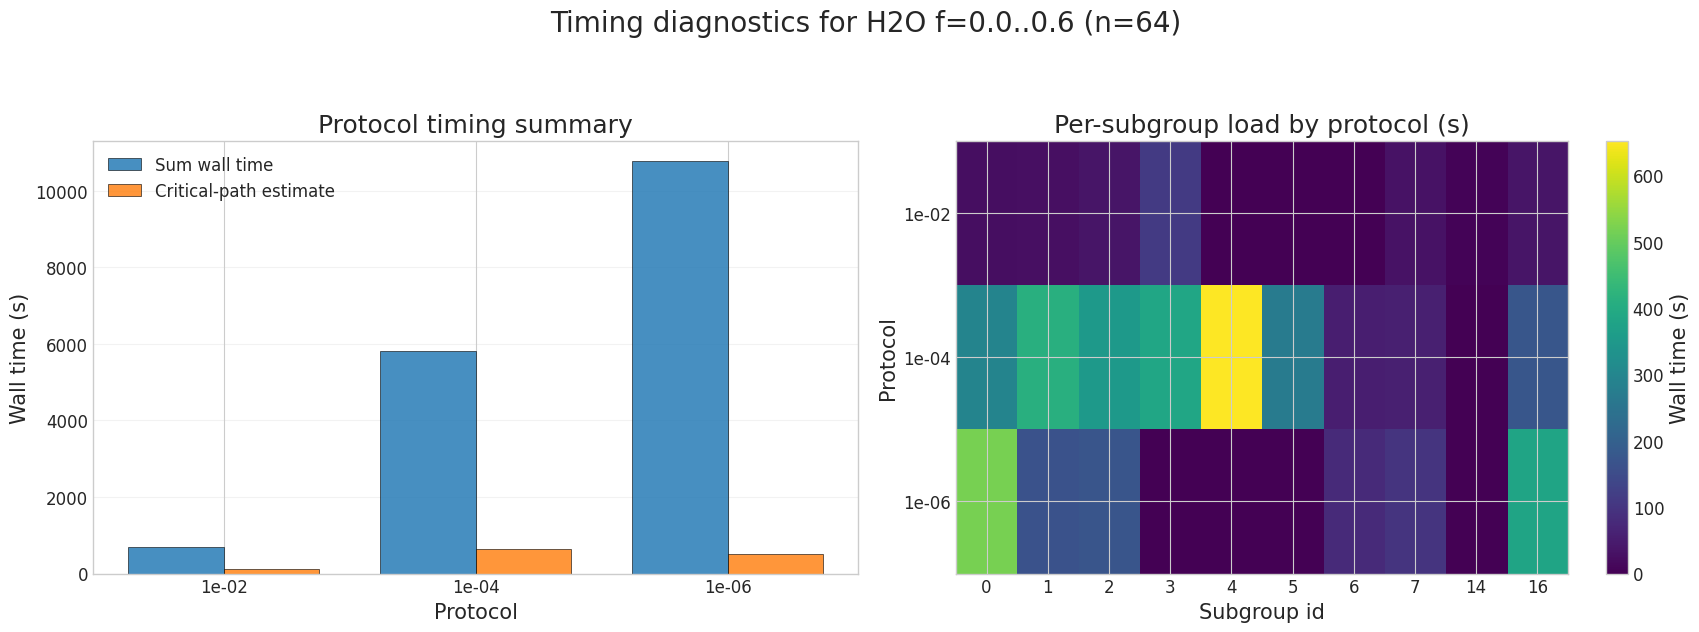

In [7]:
# Protocol timing summary (sum metric + critical-path estimate).
TIM = DF[np.isfinite(DF['wall_seconds'])].copy()
if TIM.empty:
    raise RuntimeError('No timing rows available in parsed metadata.')

TIM['owner_group_num'] = pd.to_numeric(TIM['owner_group'], errors='coerce')
all_groups = sorted(TIM.loc[np.isfinite(TIM['owner_group_num']), 'owner_group_num'].astype(int).unique().tolist())

summary_rows = []
load_matrix = np.zeros((len(PROTOCOLS), len(all_groups)), dtype=float)

for pi, protocol in enumerate(PROTOCOLS):
    sub = TIM[TIM['protocol'] == protocol].copy()

    protocol_sum = float(sub['wall_seconds'].sum())
    protocol_points = int(len(sub))
    protocol_conv = int(sub['converged'].sum())
    mean_iter = float(sub['iterations'].mean())
    mean_resid = float(sub['final_residual'].mean())

    owned = sub[np.isfinite(sub['owner_group_num'])].copy()
    if owned.empty:
        critical = protocol_sum
    else:
        grp_load = owned.groupby('owner_group_num')['wall_seconds'].sum()
        critical = float(grp_load.max())
        for gj, gid in enumerate(all_groups):
            load_matrix[pi, gj] = float(grp_load.get(gid, 0.0))

    summary_rows.append({
        'protocol': protocol,
        'points_with_timing': protocol_points,
        'points_converged': protocol_conv,
        'mean_iterations': mean_iter,
        'mean_final_residual': mean_resid,
        'sum_wall_s': protocol_sum,
        'critical_path_est_s': critical,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(17.5, 6.2))

x = np.arange(len(PROTOCOLS), dtype=float)
width = 0.38
axes[0].bar(
    x - width / 2,
    summary_df['sum_wall_s'].to_numpy(dtype=float),
    width=width,
    alpha=0.82,
    edgecolor='black',
    linewidth=0.5,
    label='Sum wall time',
)
axes[0].bar(
    x + width / 2,
    summary_df['critical_path_est_s'].to_numpy(dtype=float),
    width=width,
    alpha=0.82,
    edgecolor='black',
    linewidth=0.5,
    label='Critical-path estimate',
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(PROTOCOLS)
axes[0].set_xlabel('Protocol')
axes[0].set_ylabel('Wall time (s)')
axes[0].set_title('Protocol timing summary')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(loc='best')

if len(all_groups) == 0:
    axes[1].text(0.5, 0.5, 'No owner_group info available', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_axis_off()
else:
    im = axes[1].imshow(load_matrix, aspect='auto', cmap='viridis')
    axes[1].set_yticks(np.arange(len(PROTOCOLS)))
    axes[1].set_yticklabels(PROTOCOLS)
    axes[1].set_xticks(np.arange(len(all_groups)))
    axes[1].set_xticklabels(all_groups)
    axes[1].set_xlabel('Subgroup id')
    axes[1].set_ylabel('Protocol')
    axes[1].set_title('Per-subgroup load by protocol (s)')
    cbar = fig.colorbar(im, ax=axes[1])
    cbar.set_label('Wall time (s)')

plt.suptitle('Timing diagnostics for H2O f=0.0..0.6 (n=64)', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



In [8]:
# Polarizability tensor components vs frequency (xx, yy, zz, and isotropic average).
import re


def extract_alpha_tensor_df_from_calc(calc):
    if calc is None:
        return pd.DataFrame()

    alpha = calc.data.get('alpha')
    if not isinstance(alpha, dict) or not alpha:
        return pd.DataFrame()

    omega = np.asarray(alpha.get('omega', []), dtype=float).reshape(-1)
    values = np.asarray(alpha.get('values', []), dtype=float)
    comps = [str(c).lower() for c in alpha.get('components', [])]

    if omega.size == 0 or values.size == 0:
        return pd.DataFrame()

    if values.ndim == 1:
        if comps and values.size % len(comps) == 0:
            values = values.reshape(-1, len(comps))
        elif omega.size > 0 and values.size % omega.size == 0:
            values = values.reshape(omega.size, -1)
        else:
            return pd.DataFrame()

    if values.shape[0] != omega.size:
        if values.ndim == 2 and values.shape[1] == omega.size:
            values = values.T
        else:
            return pd.DataFrame()

    if comps and len(comps) == values.shape[1]:
        comp_to_idx = {c: i for i, c in enumerate(comps)}
        required = ('xx', 'yy', 'zz')
        if not all(c in comp_to_idx for c in required):
            return pd.DataFrame()
        ixx, iyy, izz = comp_to_idx['xx'], comp_to_idx['yy'], comp_to_idx['zz']
    elif values.shape[1] >= 9:
        ixx, iyy, izz = 0, 4, 8
    else:
        return pd.DataFrame()

    out = pd.DataFrame({
        'frequency': omega,
        'alpha_xx': values[:, ixx],
        'alpha_yy': values[:, iyy],
        'alpha_zz': values[:, izz],
    }).sort_values('frequency').reset_index(drop=True)
    out['alpha_iso'] = (out['alpha_xx'] + out['alpha_yy'] + out['alpha_zz']) / 3.0
    out['source'] = 'gecko_alpha'
    return out


def extract_alpha_tensor_df_from_console(molresponse_dir):
    log_files = sorted(Path(molresponse_dir).glob('response_console.group*.log'))
    if not log_files:
        return pd.DataFrame()

    start_re = re.compile(
        r"Starting response solve for\s+(?P<state>\S+)\s+at thresh\s+(?P<thresh>[0-9.eE+-]+)\s+freq\s+(?P<freq>[0-9.eE+-]+)"
    )
    alpha_re = re.compile(r"\[alpha\].*?Value:\s*(?P<alpha>[+-]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[eE][+-]?\d+)?)")
    final_re = re.compile(
        r"Final solver diagnostics for\s+(?P<state>\S+)\s+at thresh\s+(?P<thresh>[0-9.eE+-]+)\s+freq\s+(?P<freq>[0-9.eE+-]+)"
    )

    active_point = None
    active_alpha = {}
    records = {}

    def norm_key(state, thresh_str, freq_str):
        try:
            thresh = float(thresh_str)
            freq = float(freq_str)
        except Exception:
            return None
        return (state, round(thresh, 14), round(freq, 12))

    for log_file in log_files:
        try:
            lines = log_file.read_text(errors='ignore').splitlines()
        except Exception:
            continue

        for line in lines:
            m = start_re.search(line)
            if m:
                key = norm_key(m.group('state'), m.group('thresh'), m.group('freq'))
                active_point = key
                continue

            m = alpha_re.search(line)
            if m and active_point is not None:
                try:
                    active_alpha[active_point] = float(m.group('alpha'))
                except Exception:
                    pass
                continue

            m = final_re.search(line)
            if m:
                key = norm_key(m.group('state'), m.group('thresh'), m.group('freq'))
                if key is None:
                    continue
                alpha_val = active_alpha.get(key, np.nan)
                records[key] = alpha_val
                if active_point == key:
                    active_point = None

    if not records:
        return pd.DataFrame()

    rows = []
    for (state, thresh, freq), alpha_val in records.items():
        rows.append({
            'state': state,
            'protocol': thresh,
            'frequency': freq,
            'alpha_component_value': alpha_val,
        })
    raw = pd.DataFrame(rows)

    # Use the most accurate protocol available (smallest threshold).
    protocols = sorted(raw['protocol'].unique())
    if not protocols:
        return pd.DataFrame()
    p_final = protocols[0]
    sub = raw[np.isclose(raw['protocol'], p_final)].copy()

    pivot = (
        sub.pivot_table(index='frequency', columns='state', values='alpha_component_value', aggfunc='first')
        .sort_index()
        .reset_index()
    )

    # Map dipole channels -> tensor diagonal components.
    if 'Dipole_x' not in pivot.columns or 'Dipole_y' not in pivot.columns or 'Dipole_z' not in pivot.columns:
        return pd.DataFrame()

    out = pd.DataFrame({
        'frequency': pivot['frequency'].to_numpy(dtype=float),
        'alpha_xx': pivot['Dipole_x'].to_numpy(dtype=float),
        'alpha_yy': pivot['Dipole_y'].to_numpy(dtype=float),
        'alpha_zz': pivot['Dipole_z'].to_numpy(dtype=float),
    }).sort_values('frequency').reset_index(drop=True)
    out['alpha_iso'] = (out['alpha_xx'] + out['alpha_yy'] + out['alpha_zz']) / 3.0
    out['source'] = f'console_fallback_protocol_{p_final:.0e}'
    return out


alpha_df = extract_alpha_tensor_df_from_calc(CALC)
if alpha_df.empty:
    alpha_df = extract_alpha_tensor_df_from_console(MOLRESPONSE_DIR)

if alpha_df.empty:
    print('No parseable polarizability tensor data found (neither gecko alpha nor console fallback).')
else:
    fig, ax = plt.subplots(1, 1, figsize=(12.5, 6.4))

    ax.plot(alpha_df['frequency'], alpha_df['alpha_xx'], marker='o', markersize=3.5, linewidth=1.5, alpha=0.85, label='alpha_xx')
    ax.plot(alpha_df['frequency'], alpha_df['alpha_yy'], marker='s', markersize=3.2, linewidth=1.5, alpha=0.85, label='alpha_yy')
    ax.plot(alpha_df['frequency'], alpha_df['alpha_zz'], marker='^', markersize=3.2, linewidth=1.5, alpha=0.85, label='alpha_zz')
    ax.plot(alpha_df['frequency'], alpha_df['alpha_iso'], color='black', linewidth=2.0, alpha=0.9, label='alpha_iso')

    ax.set_xlabel('Frequency (a.u.)')
    ax.set_ylabel('Polarizability (a.u.)')
    ax.set_title(f'Polarizability tensor components vs frequency ({alpha_df["source"].iloc[0]})')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')
    add_frequency_index_axis(ax, alpha_df['frequency'].to_numpy())

    plt.tight_layout()
    plt.show()

    display(alpha_df[['frequency', 'alpha_xx', 'alpha_yy', 'alpha_zz', 'alpha_iso']].head(12))



No parseable polarizability tensor data found (neither gecko alpha nor console fallback).


In [9]:
# Iteration-level trace extraction (residual + alpha) for each state-frequency point.
import re

def _has_two_consecutive_negative(values):
    vals = np.asarray(values, dtype=float)
    if vals.size < 2:
        return False
    mask = np.isfinite(vals) & (vals < 0.0)
    return bool(np.any(mask[:-1] & mask[1:]))

def parse_iteration_traces(molresponse_dir):
    log_files = sorted(Path(molresponse_dir).glob('response_console.group*.log'))
    if not log_files:
        return pd.DataFrame()

    start_re = re.compile(
        r"Starting response solve for\s+(?P<state>\S+)\s+at thresh\s+(?P<thresh>[0-9.eE+-]+)\s+freq\s+(?P<freq>[0-9.eE+-]+)"
    )
    res_re = re.compile(
        r"\[res_norm\].*?Value:\s*(?P<value>[+-]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[eE][+-]?\d+)?)"
    )
    alpha_re = re.compile(
        r"\[alpha\].*?Value:\s*(?P<value>[+-]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[eE][+-]?\d+)?)"
    )
    final_re = re.compile(
        r"Final solver diagnostics for\s+(?P<state>\S+)\s+at thresh\s+(?P<thresh>[0-9.eE+-]+)\s+freq\s+(?P<freq>[0-9.eE+-]+)"
    )

    rows = []

    def parse_group_id(path_obj):
        m = re.search(r"group(\d+)", path_obj.name)
        return int(m.group(1)) if m else -1

    for log_file in log_files:
        gid = parse_group_id(log_file)
        active_state = None
        active_protocol = None
        active_frequency = None
        iter_idx = 0

        try:
            lines = log_file.read_text(errors='ignore').splitlines()
        except Exception:
            continue

        for line in lines:
            m = start_re.search(line)
            if m:
                try:
                    active_state = str(m.group('state'))
                    active_protocol = float(m.group('thresh'))
                    active_frequency = float(m.group('freq'))
                    iter_idx = 0
                except Exception:
                    active_state = None
                    active_protocol = None
                    active_frequency = None
                    iter_idx = 0
                continue

            if active_state is None:
                continue

            m = res_re.search(line)
            if m:
                try:
                    value = float(m.group('value'))
                except Exception:
                    value = np.nan
                iter_idx += 1
                rows.append({
                    'state': active_state,
                    'protocol_f': round(float(active_protocol), 14),
                    'frequency': float(active_frequency),
                    'freq_round': round(float(active_frequency), 12),
                    'iter': int(iter_idx),
                    'res_norm': value,
                    'alpha_iter': np.nan,
                    'owner_group': gid,
                    'log_file': log_file.name,
                })
                continue

            m = alpha_re.search(line)
            if m:
                try:
                    value = float(m.group('value'))
                except Exception:
                    value = np.nan

                if rows:
                    for i in range(len(rows) - 1, -1, -1):
                        r = rows[i]
                        if (
                            r['state'] == active_state
                            and r['protocol_f'] == round(float(active_protocol), 14)
                            and r['freq_round'] == round(float(active_frequency), 12)
                            and np.isnan(r['alpha_iter'])
                        ):
                            rows[i]['alpha_iter'] = value
                            break
                continue

            m = final_re.search(line)
            if m:
                active_state = None
                active_protocol = None
                active_frequency = None
                iter_idx = 0

    if not rows:
        return pd.DataFrame()

    trace = pd.DataFrame(rows).sort_values(['protocol_f', 'state', 'frequency', 'iter']).reset_index(drop=True)
    channel_label = {'Dipole_x': 'DipoleX', 'Dipole_y': 'DipoleY', 'Dipole_z': 'DipoleZ'}
    trace['channel'] = trace['state'].map(channel_label).fillna(trace['state'])
    return trace

TRACE = parse_iteration_traces(MOLRESPONSE_DIR)
if TRACE.empty:
    raise RuntimeError('No iteration-level trace data found in response_console logs.')

META = DF[['state', 'protocol', 'frequency', 'converged', 'final_residual', 'final_drho', 'restart_kind', 'channel']].copy()
META['protocol_f'] = pd.to_numeric(META['protocol'], errors='coerce').round(14)
META['freq_round'] = pd.to_numeric(META['frequency'], errors='coerce').round(12)
META = META.drop(columns=['protocol', 'frequency'])

TRACE = TRACE.merge(
    META,
    on=['state', 'protocol_f', 'freq_round', 'channel'],
    how='left',
)

PROTOCOL_ANALYSIS = float(np.nanmin(TRACE['protocol_f'].to_numpy(dtype=float)))
TRACE_FINAL = TRACE[np.isclose(TRACE['protocol_f'], PROTOCOL_ANALYSIS)].copy()
if TRACE_FINAL.empty:
    raise RuntimeError('No traces found at the final (smallest threshold) protocol.')

point_rows = []
for (state, channel, freq), grp in TRACE_FINAL.groupby(['state', 'channel', 'frequency'], sort=True):
    g = grp.sort_values('iter')
    point_rows.append({
        'state': state,
        'channel': channel,
        'frequency': float(freq),
        'iterations_seen': int(g['iter'].max()),
        'last_res_norm': float(g['res_norm'].dropna().iloc[-1]) if g['res_norm'].notna().any() else np.nan,
        'last_alpha': float(g['alpha_iter'].dropna().iloc[-1]) if g['alpha_iter'].notna().any() else np.nan,
        'converged': bool(g['converged'].dropna().iloc[0]) if g['converged'].notna().any() else False,
        'final_residual': float(g['final_residual'].dropna().iloc[0]) if g['final_residual'].notna().any() else np.nan,
        'restart_kind': g['restart_kind'].dropna().iloc[0] if g['restart_kind'].notna().any() else 'unknown',
        'two_negative_alpha': _has_two_consecutive_negative(g['alpha_iter'].to_numpy(dtype=float)),
        'two_negative_res_norm': _has_two_consecutive_negative(g['res_norm'].to_numpy(dtype=float)),
    })

POINT_FINAL = pd.DataFrame(point_rows).sort_values(['channel', 'frequency']).reset_index(drop=True)
POINT_FINAL['is_problem'] = (~POINT_FINAL['converged']) | POINT_FINAL['two_negative_alpha'] | POINT_FINAL['two_negative_res_norm']

print(f'Final-protocol trace rows: {len(TRACE_FINAL)}')
print(f'Final protocol threshold: {PROTOCOL_ANALYSIS:.3e}')
print(f'Unique final-protocol points: {len(POINT_FINAL)}')
print(f'Problem points (unconverged or two negative alpha in a row): {int(POINT_FINAL["is_problem"].sum())}')

display(
    POINT_FINAL[POINT_FINAL['is_problem']]
    .sort_values(['converged', 'final_residual'], ascending=[True, False])
    [['channel', 'state', 'frequency', 'converged', 'iterations_seen', 'final_residual', 'last_res_norm', 'last_alpha', 'two_negative_alpha', 'restart_kind']]
    .head(20)
)

display(
    POINT_FINAL[~POINT_FINAL['is_problem']]
    .sort_values(['final_residual', 'iterations_seen'], ascending=[True, True])
    [['channel', 'state', 'frequency', 'converged', 'iterations_seen', 'final_residual', 'last_res_norm', 'last_alpha', 'restart_kind']]
    .head(20)
)


RuntimeError: No iteration-level trace data found in response_console logs.

/tmp/ipykernel_719859/2034331107.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  freq_cmap = cm.get_cmap('viridis')
/tmp/ipykernel_719859/2034331107.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


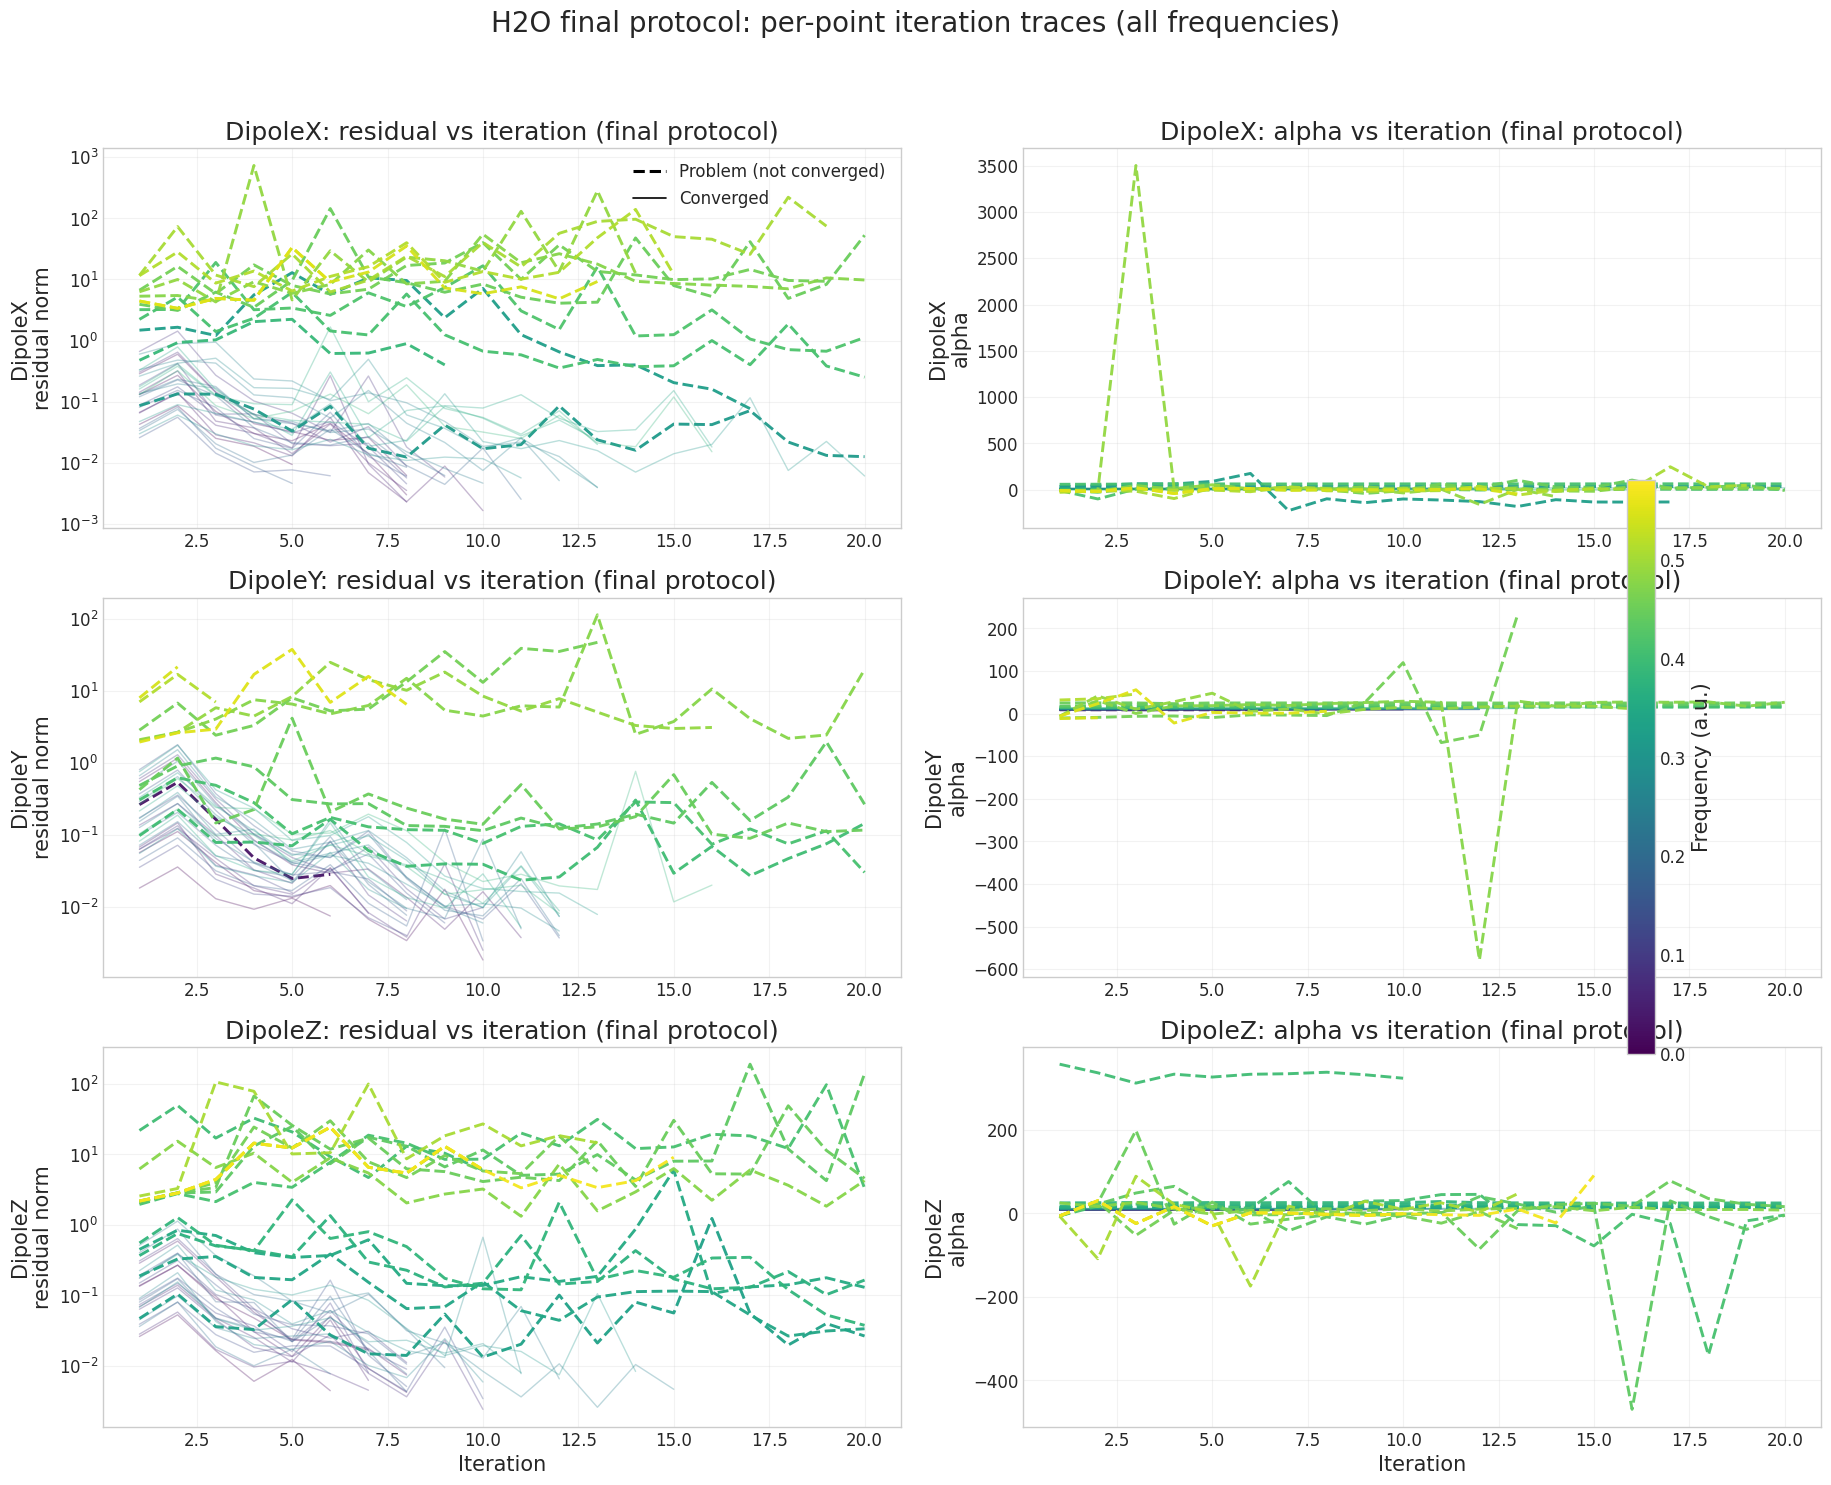

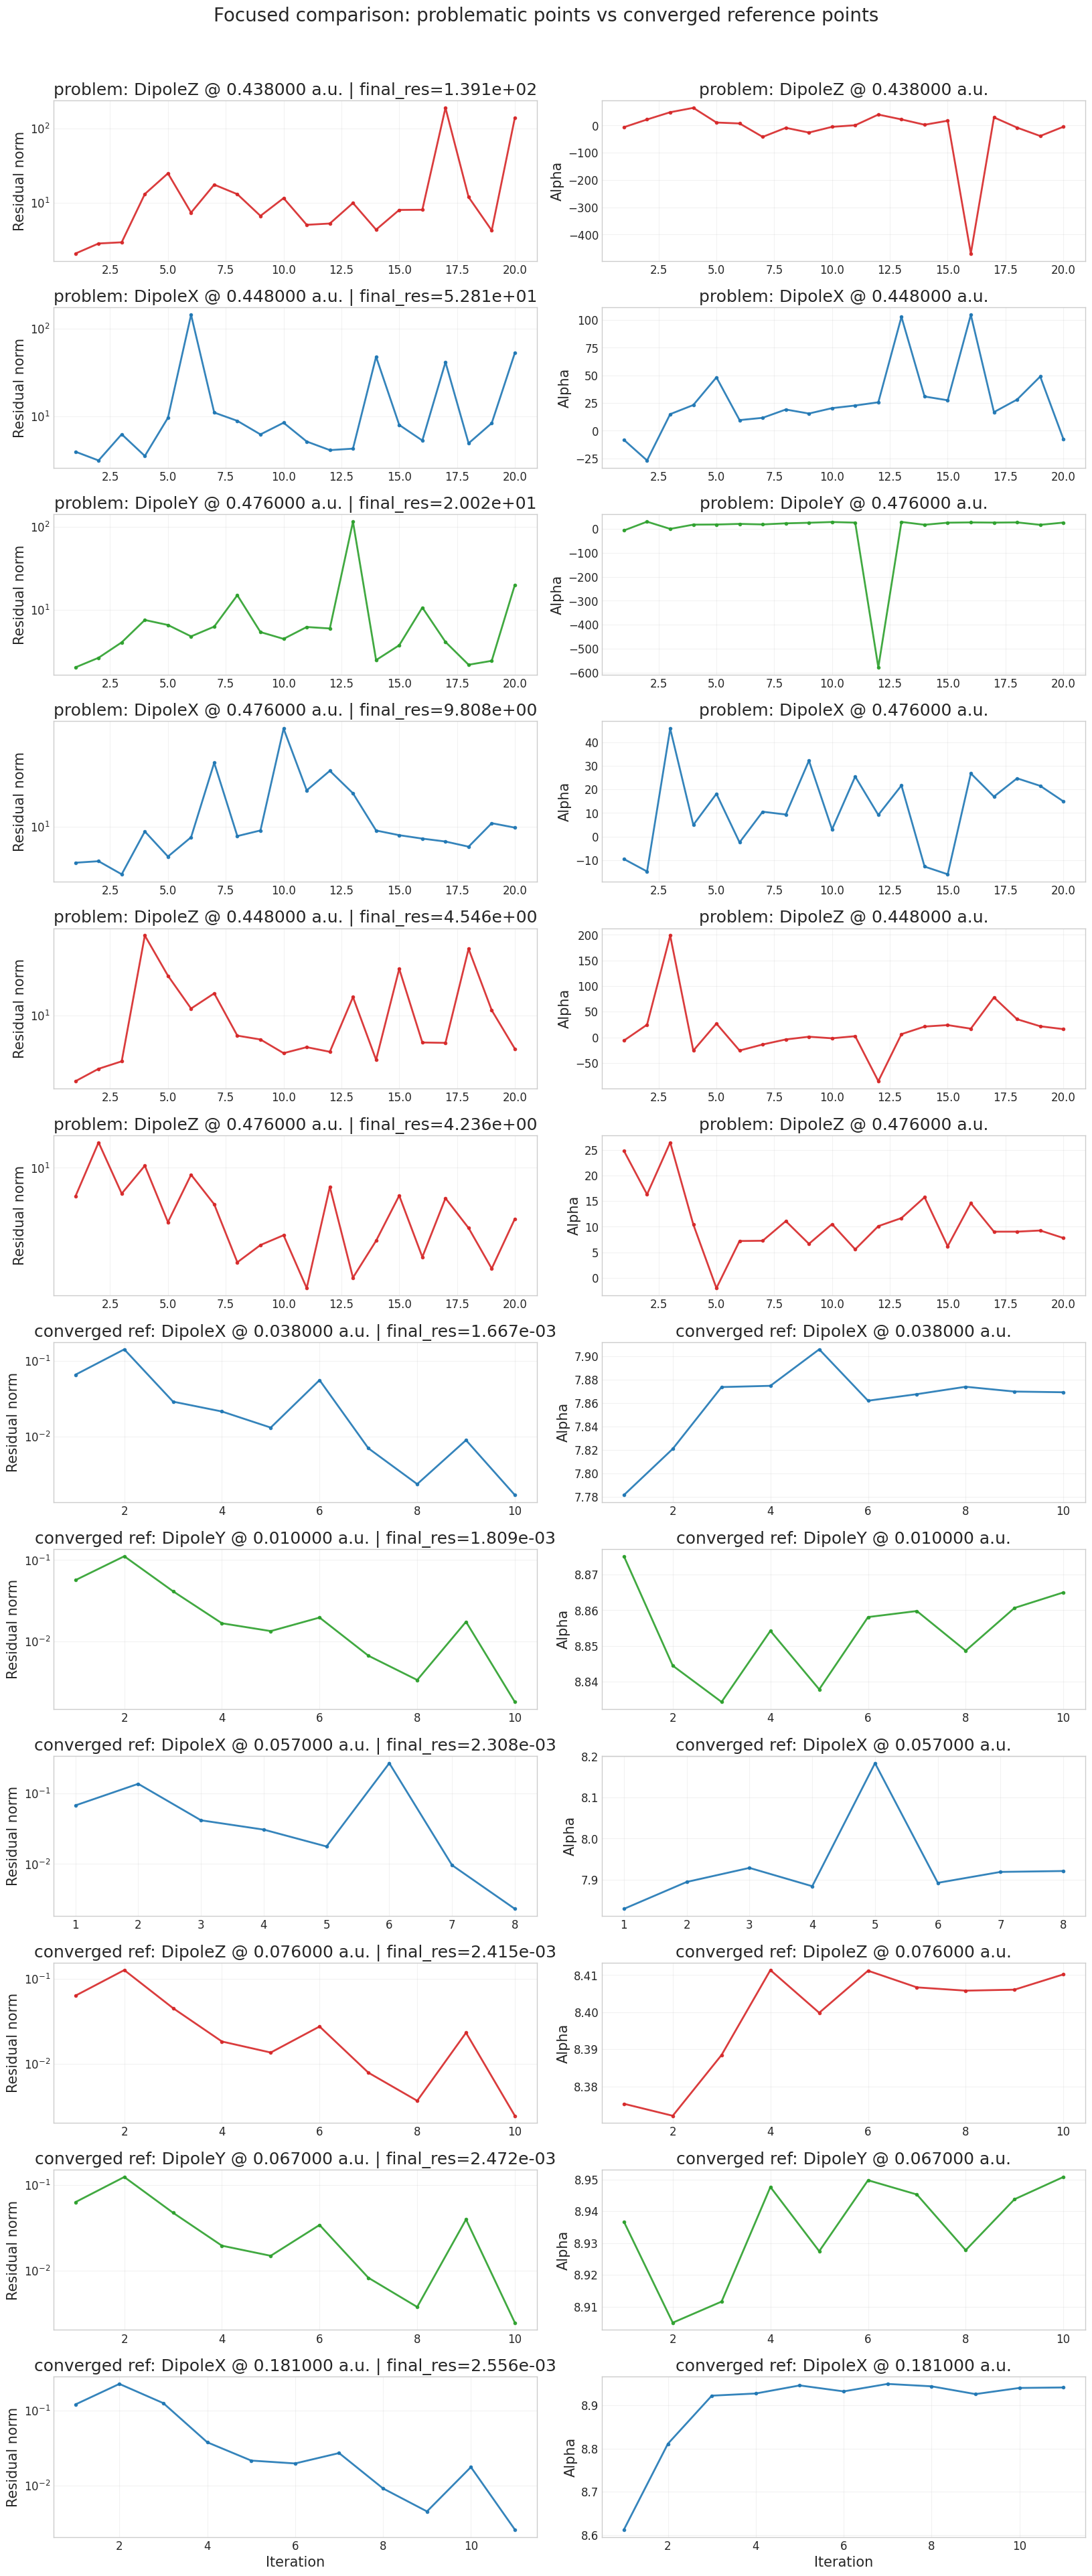

In [ ]:
# Iteration plots: all final-protocol points + focused problem vs converged comparison.
from matplotlib import cm
from matplotlib.colors import Normalize

trace_plot = TRACE_FINAL.copy()
trace_plot['is_problem'] = (~trace_plot['converged'].fillna(False))

freq_vals = trace_plot['frequency'].to_numpy(dtype=float)
freq_norm = Normalize(vmin=float(np.nanmin(freq_vals)), vmax=float(np.nanmax(freq_vals)))
freq_cmap = cm.get_cmap('viridis')

fig, axes = plt.subplots(len(channel_order), 2, figsize=(18.5, 4.9 * len(channel_order)), sharex=False)
if len(channel_order) == 1:
    axes = np.array([axes])

for i, channel in enumerate(channel_order):
    ax_res = axes[i, 0]
    ax_alpha = axes[i, 1]

    sub = trace_plot[trace_plot['channel'] == channel].copy()
    for (state, freq), grp in sub.groupby(['state', 'frequency'], sort=True):
        g = grp.sort_values('iter')
        is_problem = bool((~g['converged'].fillna(False)).iloc[0])
        color = freq_cmap(freq_norm(float(freq)))
        style = '--' if is_problem else '-'
        lw = 2.1 if is_problem else 1.0
        alpha = 0.95 if is_problem else 0.30

        res_vals = np.asarray(g['res_norm'].to_numpy(dtype=float), dtype=float)
        res_vals = np.clip(res_vals, 1e-15, np.inf)
        ax_res.plot(g['iter'], res_vals, linestyle=style, color=color, linewidth=lw, alpha=alpha)

        ax_alpha.plot(g['iter'], g['alpha_iter'], linestyle=style, color=color, linewidth=lw, alpha=alpha)

    ax_res.set_yscale('log')
    ax_res.set_ylabel(f'{channel}\nresidual norm')
    ax_res.grid(alpha=0.25)
    ax_res.set_title(f'{channel}: residual vs iteration (final protocol)')

    ax_alpha.set_ylabel(f'{channel}\nalpha')
    ax_alpha.grid(alpha=0.25)
    ax_alpha.set_title(f'{channel}: alpha vs iteration (final protocol)')

axes[-1, 0].set_xlabel('Iteration')
axes[-1, 1].set_xlabel('Iteration')

legend_handles = [
    Line2D([0], [0], color='black', lw=2.2, linestyle='--', label='Problem (not converged)'),
    Line2D([0], [0], color='black', lw=1.2, linestyle='-', label='Converged'),
]
axes[0, 0].legend(handles=legend_handles, loc='upper right')

sm = cm.ScalarMappable(norm=freq_norm, cmap=freq_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01)
cbar.set_label('Frequency (a.u.)')

plt.suptitle('H2O final protocol: per-point iteration traces (all frequencies)', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

problem_points = (
    POINT_FINAL[POINT_FINAL['is_problem']]
    .sort_values(['converged', 'final_residual'], ascending=[True, False])
    .head(6)
)
good_points = (
    POINT_FINAL[~POINT_FINAL['is_problem']]
    .sort_values(['final_residual', 'iterations_seen'], ascending=[True, True])
    .head(6)
)

compare_rows = pd.concat([
    problem_points.assign(class_label='problem'),
    good_points.assign(class_label='converged_ref'),
], ignore_index=True)

if compare_rows.empty:
    print('No points available for focused comparison plot.')
else:
    nrows = len(compare_rows)
    fig, axes = plt.subplots(nrows, 2, figsize=(16.5, max(3.2 * nrows, 8.0)), sharex=False)
    if nrows == 1:
        axes = np.array([axes])

    for i, row in compare_rows.reset_index(drop=True).iterrows():
        sel = trace_plot[(trace_plot['state'] == row['state']) & np.isclose(trace_plot['frequency'], row['frequency'])].copy()
        sel = sel.sort_values('iter')

        color = channel_colors.get(row['channel'], '#444444')
        label = f"{row['channel']} @ {row['frequency']:.6f} a.u."

        ax_res = axes[i, 0]
        ax_alpha = axes[i, 1]

        if sel.empty:
            ax_res.text(0.5, 0.5, 'No trace rows found', ha='center', va='center', transform=ax_res.transAxes)
            ax_alpha.text(0.5, 0.5, 'No trace rows found', ha='center', va='center', transform=ax_alpha.transAxes)
        else:
            rv = np.asarray(sel['res_norm'].to_numpy(dtype=float), dtype=float)
            rv = np.clip(rv, 1e-15, np.inf)
            ax_res.plot(sel['iter'], rv, color=color, linewidth=2.0, alpha=0.9, marker='o', markersize=3.0)
            ax_res.set_yscale('log')

            ax_alpha.plot(sel['iter'], sel['alpha_iter'], color=color, linewidth=2.0, alpha=0.9, marker='o', markersize=3.0)

        status_txt = 'problem' if row['class_label'] == 'problem' else 'converged ref'
        ax_res.set_title(f"{status_txt}: {label} | final_res={row['final_residual']:.3e}")
        ax_alpha.set_title(f"{status_txt}: {label}")
        ax_res.grid(alpha=0.25)
        ax_alpha.grid(alpha=0.25)
        ax_res.set_ylabel('Residual norm')
        ax_alpha.set_ylabel('Alpha')

    axes[-1, 0].set_xlabel('Iteration')
    axes[-1, 1].set_xlabel('Iteration')

    plt.suptitle('Focused comparison: problematic points vs converged reference points', y=1.002)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()
